In [70]:
!pip install gymnasium

# Import the libraries needed for the project

In [71]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# here we begin to Create game

In [72]:
env = gym.make("FrozenLake-v1", is_slippery=False)
print("FrozenLake environment created successfully.")

FrozenLake environment created successfully.


# Check the number of states and actions in the game

In [73]:
number_of_states = env.observation_space.n
number_of_actions = env.action_space.n

print("Number of states:", number_of_states)
print("Number of actions:", number_of_actions)

Number of states: 16
Number of actions: 4


# here i proceed to Create Q-table

In [74]:
q_table = np.zeros((number_of_states, number_of_actions))

print("Q-table size:", q_table.shape)

Q-table size: (16, 4)


# Setting values

In [75]:
learning_rate = 0.8
discount_rate = 0.95

epsilon = 1.0
epsilon_decay = 0.001
minimum_epsilon = 0.01

episodes = 2000
max_steps = 100

# Train the agent using Q-learning

In [76]:
rewards = []

for episode in range(episodes):
    state, info = env.reset()
    total = 0

    for step in range(max_steps):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        new_state, reward, done, stopped, info = env.step(action)

        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_rate * np.max(q_table[new_state]) - q_table[state, action]
        )

        state = new_state
        total = total + reward

        if done or stopped:
            break

    epsilon = max(minimum_epsilon, epsilon - epsilon_decay)
    rewards.append(total)

print("Done")

Done


#Show Final Q-Table

In [77]:
print(np.round(q_table, 2))

[[0.74 0.77 0.77 0.74]
 [0.74 0.   0.81 0.77]
 [0.77 0.86 0.77 0.81]
 [0.81 0.   0.77 0.77]
 [0.77 0.81 0.   0.74]
 [0.   0.   0.   0.  ]
 [0.   0.9  0.   0.81]
 [0.   0.   0.   0.  ]
 [0.81 0.   0.86 0.77]
 [0.81 0.9  0.9  0.  ]
 [0.86 0.95 0.   0.86]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.9  0.95 0.86]
 [0.9  0.95 1.   0.9 ]
 [0.   0.   0.   0.  ]]


#Plot Rewards

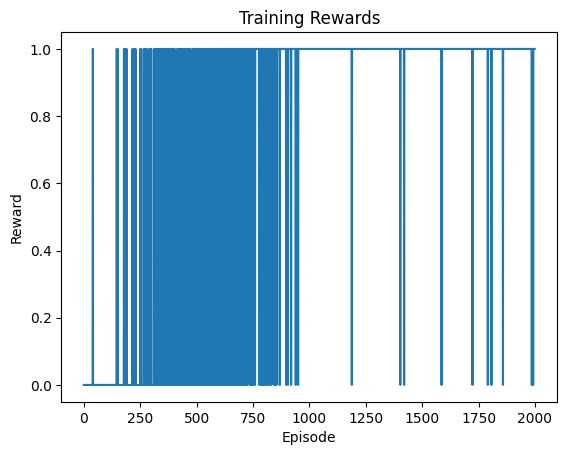

In [78]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards")
plt.savefig("training_rewards.png")
plt.show()

#Plot Average Reward

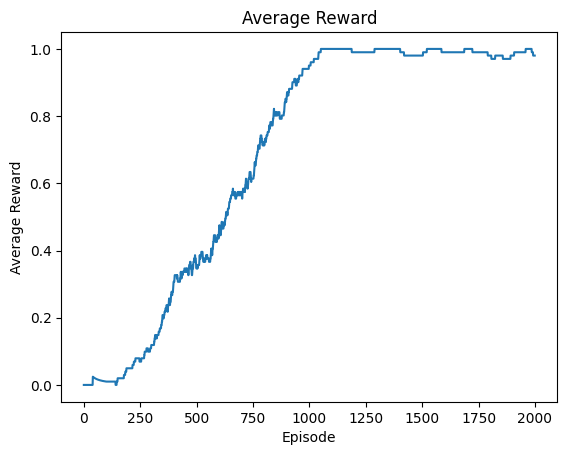

In [79]:
average = []

for i in range(len(rewards)):
    average.append(np.mean(rewards[max(0, i-100):i+1]))

plt.plot(average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Average Reward")
plt.savefig("average_reward.png")
plt.show()

#Test the Agent

In [80]:
success = 0

for episode in range(100):
    state, info = env.reset()

    for step in range(max_steps):
        action = np.argmax(q_table[state])
        state, reward, done, stopped, info = env.step(action)

        if done or stopped:
            if reward == 1:
                success = success + 1
            break

print("Success:", success, "out of 100")

Success: 100 out of 100


#Plot Success Rate

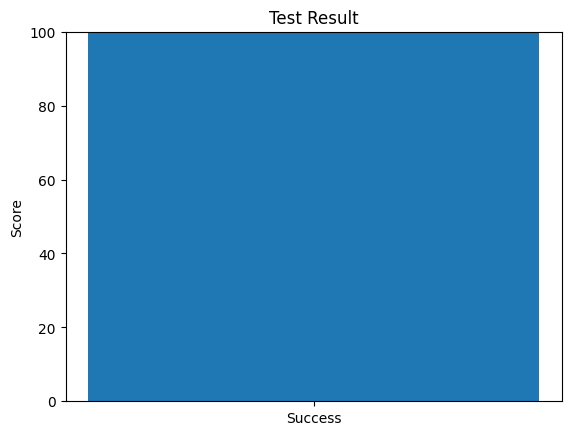

In [81]:
plt.bar(["Success"], [success])
plt.ylim(0, 100)
plt.ylabel("Score")
plt.title("Test Result")
plt.savefig("test_result.png")
plt.show()

#Create Visible Game

In [82]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

#Watch Agent Play

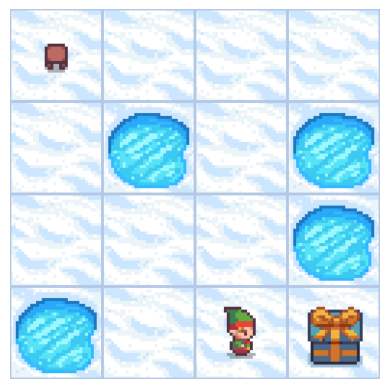

Goal reached


In [83]:
from IPython.display import clear_output
import time

state, info = env.reset()

for i in range(20):
    clear_output(wait=True)

    plt.imshow(env.render())
    plt.axis("off")
    plt.show()

    action = np.argmax(q_table[state])
    state, reward, done, stopped, info = env.step(action)

    time.sleep(0.5)

    if done or stopped:
        break

if reward == 1:
    print("Goal reached")
else:
    print("Game ended")